# (22) lightening play

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

In [3]:
from lite.ipvae import LiteIPVAE
from base.dataset import make_dataloader

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint

In [4]:
project_dir = add_home('Projects/PoissonVAE')
os.makedirs(project_dir, exist_ok=True)
print(sorted(os.listdir(project_dir)))

['litmodels', 'models', 'results', 'runs', 'wandb']

In [5]:
chkpt_dir = pjoin(project_dir, 'litmodels')
os.makedirs(chkpt_dir, exist_ok=True)
print(sorted(os.listdir(chkpt_dir)))

[]

In [6]:
wandb_logger = WandbLogger(
    project='ipvae-lite',
    name='yateslab',
    save_code=True,
    save_dir=project_dir,
)

In [7]:
trainer = pl.Trainer(
    max_epochs=50,
    gradient_clip_val=200.0,
    logger=wandb_logger,
    accelerator='gpu',
    devices=[device_idx],
    callbacks=[ModelCheckpoint(dirpath='./checkpoints')],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [8]:
# import torch
# torch.set_float32_matmul_precision('medium')

In [9]:
dl_trn, dl_vld = make_dataloader('vH16-wht', device, batch_size=10)

In [10]:
ipvae = LiteIPVAE(
    t_train=10,
    beta_kl=10.0,
    input_dim=256,
    latent_dim=512,
    recon_mode='mse',
)

In [11]:
trainer.fit(ipvae, dl_trn)

You are using a CUDA device ('NVIDIA RTX 6000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: vafaii (yateslab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading `train_dataloader` to estimate number of stepping batches.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name       | Type      | Params | Mode 
-------------------------------------------------
0 | core_model | CoreIPVAE | 132 K  | train
-------------------------------------------------
132 K     Trainable params
0         Non-trainable params
132 K     Total params
0.529     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Training: |                                               | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [12]:
self = ipvae.core_model

In [16]:
w = tonp(self.dec.weight.data)
w = w.T.reshape(-1, 16, 16)
w.shape

(512, 16, 16)

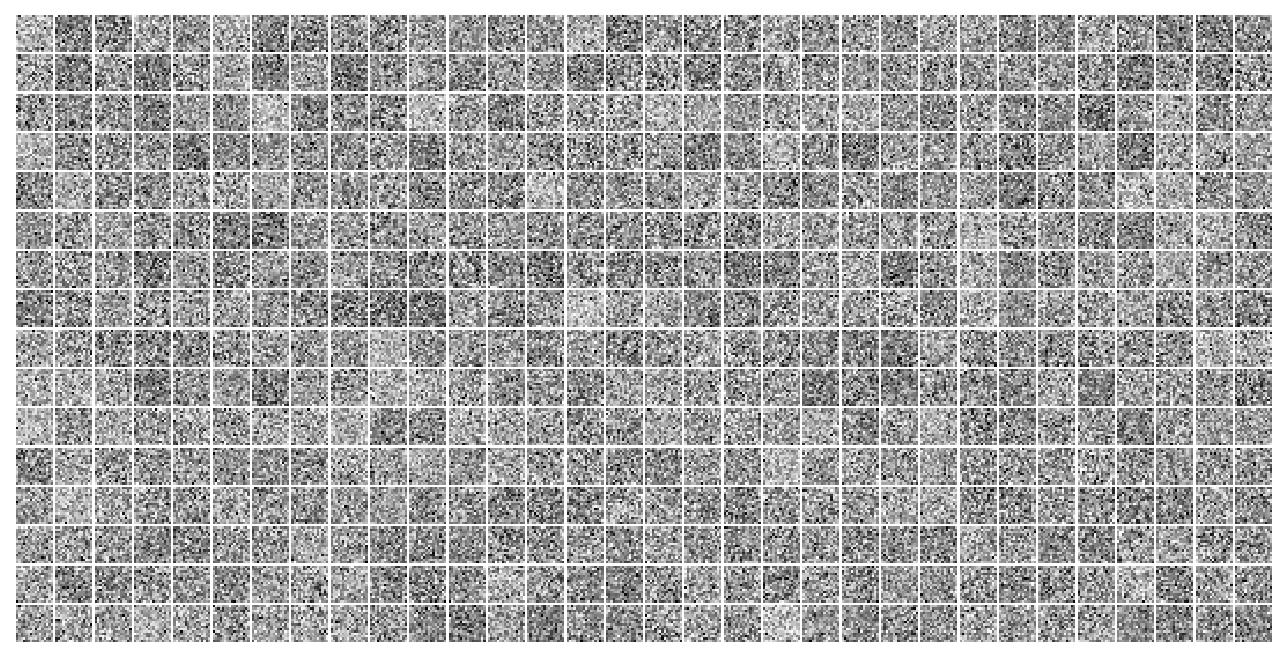

In [18]:
plot_weights(w);

In [18]:
y = self.dec(self.samples)

self.samples.shape, y.shape

(torch.Size([200, 512]), torch.Size([200, 256]))

In [19]:
self.dec.weight.data

tensor([[ 0.4459,  1.8236, -0.0636,  ...,  0.5143,  2.1891, -0.4013],
        [ 0.0668, -1.4438, -1.4960,  ..., -0.1500, -1.4424,  0.5232],
        [-0.0601, -1.2109,  0.6898,  ...,  1.3435,  0.5855, -1.0559],
        ...,
        [ 1.3908, -0.5595, -0.7890,  ..., -0.0838, -0.4125,  0.1302],
        [ 0.7800,  0.0071,  0.2925,  ..., -1.6118,  0.8042, -0.6821],
        [-1.1207,  0.0259,  0.2086,  ..., -0.1205,  0.8682,  0.2320]])

In [ ]:
# 2. Setup Wandb logger


# 3. Create trainer
trainer = pl.Trainer(
    max_epochs=50,
    logger=wandb_logger,
    accelerator="auto",
)

# 4. Train
trainer.fit(model, your_dataloader)

# 5. Cleanup
wandb.finish()

In [ ]:
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
import wandb

# Assuming you already have:
# - your_dataloader (training data)
# - LitIPVAE imported

# 1. Initialize model
model = LitIPVAE(
    t_train=10,
    beta_kl=1.0,
    input_dim=784,  # adjust to your data
    latent_dim=64,
    learning_rate=2e-3,
)

# 2. Setup Wandb logger
wandb_logger = WandbLogger(project="ipvae-training")

# 3. Create trainer
trainer = pl.Trainer(
    max_epochs=50,
    logger=wandb_logger,
    accelerator="auto",
)

# 4. Train
trainer.fit(model, your_dataloader)

# 5. Cleanup
wandb.finish()

In [22]:
from main.layers import LinearDictionary
from main.distributions import Normal, Poisson, softclamp_upper, compute_n_exp

import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F

from contextlib import contextmanager


class CoreIPVAE(nn.Module):
    def __init__(
            self,
            t_train: int,
            input_dim: int,
            latent_dim: int,
            recon_mode: str = 'prob',
    ):
        super().__init__()
    
        self.t_train = t_train
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.recon_mode = recon_mode
    
        self.n_updates = 0
        self.time = 0
        self.state = None
        self.samples = None
        self.posterior = None
        self.conditional = None
    
        self._init()
    
    def forward(self, x, temp: float = None):
        if self.time == 0 or self.state is None:
            self.reset_state(len(x))
        # (1) perform a single natural gradient update
        with self.temporary_temperature(temp):
            du = self.infer(x)
        # (2) generate from the updated posterior
        self.generate()
        # (3) compute losses
        loss_kl = self.loss_kl(du)
        loss_recon = self.loss_recon(x)
        loss = ...
        return loss
    
    def infer(self, x):
        self.n_updates += 1
        ngd_f = self.grad_free_energy(x)
        u_dot = ngd_f.mul(-1.0)
        du = self.softclamp(u_dot, 'du')
        u = self.state + du
        self.state = self.softclamp(u, 'u')
        return du
    
    def generate(self, temp: float = None):
        self.update_inference_state(temp)
        self.conditional = Normal(
            loc=self.dec(self.samples),
            log_scale=torch.zeros_like(self.samples),
            # log_scale=self.get_dec_log_sigma(),
            clamp=None,
            temp=1.0,
        )
        return self.conditional
    
    def update_inference_state(self, temp: float = None):
        with self.temporary_temperature(temp):
            self.posterior = self.get_dist()
        self.samples = self.posterior.rsample()
        return
    
    @contextmanager
    def temporary_temperature(self, temp):
        if temp is None:
            yield  # do nothing, just yield control
            return
    
        temp_orig = self.temp.item()  # store the original
        self.update_temp(temp)  # set new temperature
        try:
            yield  # run whatever needs the new temp
        finally:
            self.update_temp(temp_orig)  # revert back
    
    def reset_state(self, batch_size: int = None):
        size = (batch_size, -1)
        self.state = self.state_init.expand(size=size)
        self.n_updates = 0
        self.time = 0
        return
    
    def grad_free_energy(self, x):
        # when num inner iters = 1: KL contribution drops
        ngd_f = self.grad_recon_term(x) + self.log_bias.exp()
        return ngd_f
    
    def grad_recon_term(self, x):
        # (1) generate samples
        # self.generate() calls self.update_inference_state(),
        # which updates: self.posterior, self.samples
        # finally, self.generate updates: self.conditional 
        self.generate()
        # (2) generate prediction, compute precision-weighted error
        pred = self.conditional.loc
        error = (x - pred)
        # (3) apply jacobian
        error = self.dec(error, transpose=True)
        # (4) finalize
        grad_recon = error.mul(-1.0)
        return grad_recon
    
    def get_dist(self, posterior: bool = True):
        # (1) get n_exp
        try:
            n_exp = self.n_exp[self.time]
        except IndexError:
            n_exp = 'infer'
        # (2) get dist
        dist = Poisson(
            log_rate=self.state,
            temp=self.temp.clone(),
            n_exp=n_exp,
            n_exp_p=1e-3,
            clamp=None,
        )
        return dist
    
    def get_c(self, which: str):
        assert which in ['u', 'du']
        clamp_vals = {'u': 10.0, 'du': 10.0}
        c = clamp_vals.get(which, 10.0)
        return c
    
    def softclamp(self, x: torch.Tensor, which: str):
        return softclamp_upper(
            x=x,
            # x=x.clamp_(min=-10.0),  # TODO: expt
            c=self.get_c(which),
        )
    
    def loss_recon(self, x, mode: str = None):
        if mode is None:
            mode = self.recon_mode
        if mode == 'prob':
            loss = -self.conditional.log_prob(x)
            loss = torch.sum(loss, dim=-1)
        elif mode == 'mse':
            loss = (x - self.conditional.loc).pow(2)
            loss = torch.sum(loss, dim=-1)
        elif mode == 'r2':
            # don't use for training, only for eval
            loss = compute_r2(x, self.conditional.loc)
        else:
            raise NotImplementedError(mode)
        return loss
    
    def loss_kl(self, du):
        f = 1 + torch.exp(du) * (du - 1)
        kl = torch.exp(self.state) * f
        return kl
    
    def update_temp(self, new_t: float):
        if new_t is None:
            return
        assert new_t >= 0.0, "must be non-neg"
        self.temp.fill_(new_t)
        return
    
    def update_n_exp(
            self,
            rates: Union[float, List[float]],
            p: float = 1e-3, ):
        if rates is None:
            return
        if not isinstance(rates, list):
            rates = [rates] * self.t_train
        assert all(rates) > 0.0, f"must be positive, got: {rates}"
        assert len(rates) == self.t_train
        # update values
        for i, r in enumerate(rates):
            self.n_exp[i] = compute_n_exp(r, p)
        return
    
    def _init(self):
        self._init_dec()
        self._init_bias()
        self._init_prior()
        self._init_n_exp()
        self._init_temp()
        return
    
    def _init_dec(self):
        self.dec = LinearDictionary(
            dim_1=self.input_dim,
            dim_2=self.latent_dim,
        )
        return
    
    def _init_bias(self):
        log_bias = torch.zeros(
            (1, self.latent_dim),
            dtype=torch.float,
        )
        self.log_bias = nn.Parameter(
            data=log_bias - 10.0,
            requires_grad=True,
        )
        return
    
    def _init_prior(self):
        rng = get_rng(0)  # seed = 0
        size = (1, self.latent_dim)
        kws = {'size': size, 'low': -6.0, 'high': -4.0}
        # u: membrane potentials
        u_init = rng.uniform(**kws)
        u_init = torch.tensor(u_init, dtype=torch.float)
        u_init = nn.Parameter(u_init, requires_grad=True)
        self.state_init = u_init
        return
    
    def _init_n_exp(self):
        n_exp = torch.zeros(self.t_train, dtype=torch.int)
        self.register_buffer(name='n_exp', tensor=n_exp)
        self.update_n_exp(100.0)
        return
    
    def _init_temp(self):
        self.register_buffer(
            name='temp',  # poisson rsample
            tensor=torch.tensor(1.0),
        )
        return

In [20]:
ipvae = CoreIPVAE(10, 256, 512, 'mse')

In [ ]:
class LitIPVAE(pl.LightningModule):
    def __init__(
        self,
        t_train: int,
        beta_kl: float,
        # CoreIPVAE HParams
        input_dim: int,
        latent_dim: int,
        recon_mode: str = 'prob',
        # Optimizer Hparams
        learning_rate: float = 2e-3,
    ):
        super().__init__()
        self.save_hyperparameters()
        
        self.core_model = CoreIPVAE(
            t_train=self.hparams.t_train,
            input_dim=self.hparams.input_dim,
            latent_dim=self.hparams.latent_dim,
            recon_mode=self.hparams.recon_mode,
        )

    def forward(self, x_initial: torch.Tensor, temp: float = None):
        """
        Defines the forward pass for inference/prediction.
        For simplicity, this runs a single step using StationaryFeeder logic.
        If multi-step inference is needed, this would need its own loop.
        """
        # For inference, we'll use the StationaryFeeder logic implicitly
        # by just feeding the x_initial (or x_initial transformed if flatten=True)
        # for a single step (t_step=0).
        
        feeder = StationaryFeeder(x=x_initial, flatten=True)
        self.core_model.reset_state(batch_size=len(feeder))

        # Run one step
        _ = self.core_model(feeder[0], current_t_step=0, temp=temp)
        return self.core_model.conditional.loc # Return reconstruction

    def training_step(self, batch: torch.Tensor, batch_idx: int):
        """
        Defines a single training step, which processes a trajectory of self.hparams.t_train steps.
        """
        initial_x_data = batch # DataLoader provides the initial data for the feeder

        # 1. Initialize StationaryFeeder for this batch
        feeder = StationaryFeeder(x=batch, flatten=True)

        # 2. Reset recurrent state (membrane potentials)
        self.core_model.reset_state(batch_size=len(feeder))

        total_recon_loss_for_trajectory = 0.0
        total_kl_loss_for_trajectory = 0.0

        # 3. Run the inference trajectory
        for t_step in range(self.hparams.t_train):
            x_t = feeder[t_step]

            # Core model processes one step.
            # Pass current_t_step for CoreIPVAE's internal timekeeping (e.g., for n_exp array indexing)
            du_t = self.core_model(x_t, current_t_step=t_step)

            # Calculate losses for this specific step t_step
            # loss_recon uses the x_t fed at this step and the model's current conditional
            loss_recon_t = self.core_model.loss_recon(x_t)
            # loss_kl uses the du_t from this step and the model's current state
            loss_kl_t = self.core_model.loss_kl(du_t)
            loss_kl_t = torch.sum(loss_kl_t, dim=-1)  # sum across latent dim

            # Accumulate losses (mean over batch items for this step)
            total_recon_loss_for_trajectory += torch.mean(loss_recon_t)
            total_kl_loss_for_trajectory += torch.mean(loss_kl_t)

        # 4. Calculate final average loss over the trajectory
        # These are now sums of means; divide by t_train to get mean of means.
        mean_recon_loss_trajectory = total_recon_loss_for_trajectory / self.hparams.t_train
        mean_kl_loss_trajectory = total_kl_loss_for_trajectory / self.hparams.t_train
        
        total_loss = mean_recon_loss_trajectory + self.hparams.beta_kl * mean_kl_loss_trajectory

        # 5. Logging
        self.log('train_loss', total_loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log('train_recon_loss_traj', mean_recon_loss_trajectory, on_step=False, on_epoch=True, logger=True)
        self.log('train_kl_loss_traj', mean_kl_loss_trajectory, on_step=False, on_epoch=True, logger=True)
        self.log('train_last_step_recon_loss', loss_recon_t.mean(), on_step=False, on_epoch=True, logger=True) # Log last step's loss too
        self.log('train_last_step_kl_loss', loss_kl_t.mean(), on_step=False, on_epoch=True, logger=True)


        # 6. Return the final scalar loss for this trajectory
        return total_loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return optimizer

    # You would also typically define validation_step and test_step
    # For example:
    # def validation_step(self, batch, batch_idx):
    #     # Similar logic to training_step but for validation data
    #     # Ensure to call self.core_model.eval() if it has different behavior (e.g. Dropout)
    #     # though your CoreIPVAE doesn't seem to have such layers.
    #     initial_x_data = batch
    #     feeder = StationaryFeeder(x=initial_x_data, flatten=self.hparams.feeder_flatten_input)
    #     self.core_model.reset_state(batch_size=initial_x_data.size(0))
    #     # ... loop ...
    #     # ... calculate losses ...
    #     # self.log('val_loss', total_loss, on_epoch=True, prog_bar=True)
    #     # return total_loss
    #     pass

torch.optim.adamax.Adamax

In [ ]:

		# dec_log_sigma = self.get_dec_log_sigma()
		# dec_var = torch.exp(2.0 * dec_log_sigma)
		# error = (x - pred) / dec_var
		# (5) apply jacobian
		# if self._cfg.dec_type == 'lin':
		# 	error = self.dec(error, transpose=True)
		# else:
		# 	error = self.jacobian(
		# 		inputs=z,
		# 		outputs=pred,
		# 		error=error,
		# 	)
		# (6) apply activation derivative
		# error = self.apply_act_deriv_fn(error)
		# # (7) finalize
		# grad_recon = error.mul(-1.0)
		# return grad_recon